<a href="https://colab.research.google.com/github/algazer21/chaos_attractors/blob/main/ChatDaniela28dias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Whatsapp 28 días D&A

In [1]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
import re
from nltk import bigrams
import numpy as np
nltk.download('punkt')
nltk.download('stopwords')
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
txtu = "/content/drive/MyDrive/Temporal/chatDaniela.txt"
with open(txtu,'r') as file:
  chat = file.read()
patron = r'\[.*?\]'

In [3]:
fecha = re.findall(patron,chat)
splited = re.split(patron,chat)[1:]

In [4]:
Dani,Alan = [],[]
Danif,Alanf = [],[]
for fe,txt in zip(fecha,splited):
  if txt[:9] == ' Daniela:':
    Dani.append(txt[10:])
    Danif.append(fe)
  if txt[:3] == ' Z:':
    Alan.append(txt[4:])
    Alanf.append(fe)

In [5]:
bool_audAlan = np.logical_or(np.array(Alan)  == '\u200eaudio omitido\n',np.array(Alan)  == '\u200eaudio omitido\n\u200e')
bool_audDani = np.logical_or(np.array(Dani)  == '\u200eaudio omitido\n',np.array(Dani)  == '\u200eaudio omitido\n\u200e')
bool_imaAlan = np.logical_or(np.array(Alan)  == '\u200eimagen omitida\n',np.array(Alan)  == '\u200eimagen omitida\n\u200e')
bool_imaDani = np.logical_or(np.array(Dani)  == '\u200eimagen omitida\n',np.array(Dani)  == '\u200eimagen omitida\n\u200e')
bool_stiAlan = np.logical_or(np.array(Alan)  == '\u200esticker omitido\n',np.array(Alan)  == '\u200esticker omitido\n\u200e')
bool_stiDani = np.logical_or(np.array(Dani)  == '\u200esticker omitido\n',np.array(Dani)  == '\u200esticker omitido\n\u200e')
bool_gifAlan = np.logical_or(np.array(Alan)  == '\u200eGIF omitido\n',np.array(Alan)  == '\u200eGIF omitido\n\u200e')
bool_gifDani = np.logical_or(np.array(Dani)  == '\u200eGIF omitido\n',np.array(Dani)  == '\u200eGIF omitido\n\u200e')
bool_nvidAlan = np.logical_or(np.array(Alan)  == '\u200ese omitió la nota de video\n',np.array(Alan)  == '\u200ese omitió la nota de video\n\u200e')
bool_nvidDani = np.logical_or(np.array(Dani)  == '\u200ese omitió la nota de video\n',np.array(Dani)  == '\u200ese omitió la nota de video\n\u200e')
bool_vidAlan = np.logical_or(np.array(Alan)  == '\u200eVideo omitido\n',np.array(Alan)  == '\u200eVideo omitido\n\u200e')
bool_vidDani = np.logical_or(np.array(Dani)  == '\u200eVideo omitido\n',np.array(Dani)  == '\u200eVideo omitido\n\u200e')

In [6]:
print(f"Audios  : Alan: {sum(bool_audAlan)}, Daniela: {sum(bool_audDani)}")
print(f"Imagenes: Alan: {sum(bool_imaAlan)}, Daniela: {sum(bool_imaDani)}")
print(f"Stickers: Alan: {sum(bool_stiAlan)}, Daniela: {sum(bool_stiDani)}")
print(f"GIFs    : Alan: {sum(bool_gifAlan)}, Daniela: {sum(bool_gifDani)}")
print(f"Videos  : Alan: {sum(bool_vidAlan)+sum(bool_nvidAlan)}, Daniela: {sum(bool_vidDani)+sum(bool_nvidDani)}")

Audios  : Alan: 290, Daniela: 440
Imagenes: Alan: 93, Daniela: 156
Stickers: Alan: 66, Daniela: 224
GIFs    : Alan: 9, Daniela: 8
Videos  : Alan: 12, Daniela: 15


In [7]:
bool_urlAlan = np.array([False for i in range(len(Alan))])
bool_urlDani = np.array([False for i in range(len(Dani))])
for i,t in enumerate(Alan):
  if 'http' in t:
    bool_urlAlan[i] = True
for i,t in enumerate(Dani):
  if 'http' in t:
    bool_urlDani[i] = True

print(f"URL Alan: {sum(bool_urlAlan)}")
print(f"URL Daniela: {sum(bool_urlDani)}")

URL Alan: 63
URL Daniela: 63


In [8]:
AlanC = np.array(Alan)[~np.logical_or(bool_audAlan, np.logical_or(bool_stiAlan, np.logical_or(bool_gifAlan, np.logical_or(bool_vidAlan, np.logical_or(bool_nvidAlan, np.logical_or(bool_urlAlan, bool_imaAlan))))))]
DaniC = np.array(Dani)[~np.logical_or(bool_audDani, np.logical_or(bool_stiDani, np.logical_or(bool_gifDani, np.logical_or(bool_vidDani, np.logical_or(bool_nvidDani, np.logical_or(bool_urlDani, bool_imaDani))))))]
print(f"Alan: {len(Alan)} ---> {len(AlanC)}")
print(f"Daniela: {len(Dani)} ---> {len(DaniC)}")

Alan: 3619 ---> 3086
Daniela: 3503 ---> 2597


In [9]:
stop_words = stopwords.words('spanish')
stop_words.append(".")
stop_words.append("'")
stop_words.append(",")
stop_words.append("\u200e")
stop_words.append("...")
stop_words.append("?")
stop_words.append("!")
stop_words.append("''")
stop_words.append(")")
stop_words.append("``")
stop_words.append("(")
stop_words.append(":")
stop_words = set(stop_words)

tokensA = word_tokenize(" ".join(AlanC))
tokensD = word_tokenize(" ".join(DaniC))
tokensA = [word for word in tokensA if word.lower() not in stop_words]
tokensD = [word for word in tokensD if word.lower() not in stop_words]
frecuenciasA = FreqDist(tokensA)
frecuenciasD = FreqDist(tokensD)

In [10]:
def freqGra(fre,num,color,name,tok):
  palabras_comunes = fre.most_common(num)

  # Separar palabras y sus frecuencias para el gráfico
  palabras, frecs = zip(*palabras_comunes)

  # Crear el gráfico de barras horizontales
  plt.figure(figsize=(10, 8))
  plt.barh(palabras, frecs, color=color)
  plt.xlabel('Frecuencia')
  plt.ylabel('Palabras')
  plt.title('21 Palabras Más Comunes'+' '+name)
  leyenda = f"Vocabulario: {len(fre)}\nPalabras Totales: {len(tok)}"
  plt.legend([leyenda], loc='lower right')
  plt.gca().invert_yaxis()
  plt.show()

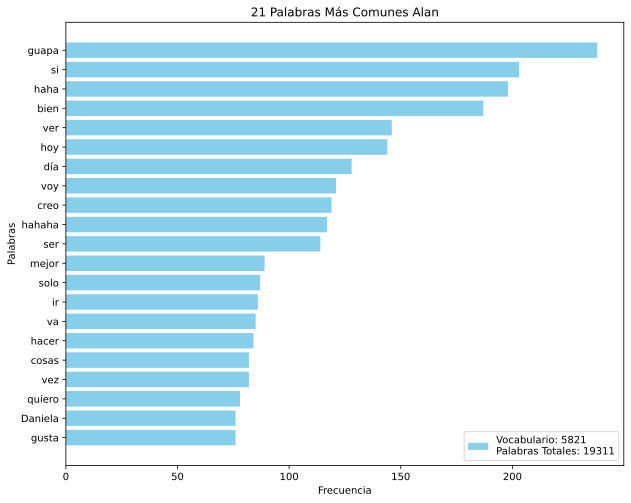

In [11]:
freqGra(frecuenciasA,21,'skyblue','Alan',tokensA)

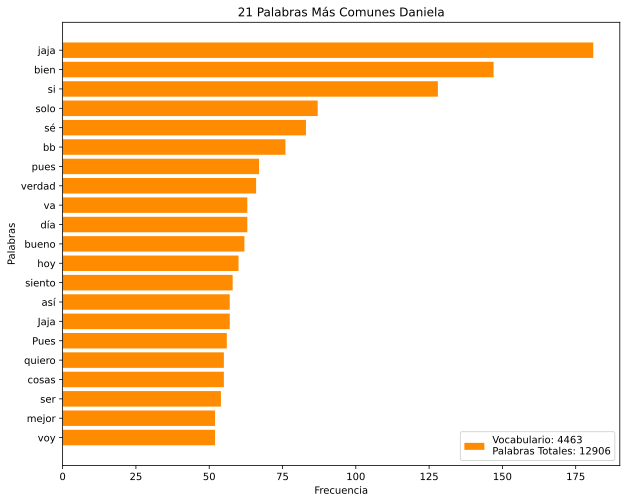

In [12]:
freqGra(frecuenciasD,21,'darkorange','Daniela',tokensD)

In [13]:
a = len(sent_tokenize(" ".join(AlanC)))
d = len(sent_tokenize(" ".join(DaniC)))
print(f"Sentencias totales.\nAlan: {a}, Daniela: {d}")

Sentencias totales.
Alan: 2983, Daniela: 1404


In [14]:
def freqBi(fre,num,color,name):
  palabras_comunes = fre.most_common(num+3)

  # Separar palabras y sus frecuencias para el gráfico
  palabras, frecs = zip(*palabras_comunes)

  # Crear el gráfico de barras horizontales
  labels = [' '.join(bigrama) for bigrama in palabras]
  plt.figure(figsize=(10, 8))
  plt.barh(labels[3:], frecs[3:], color=color)
  plt.xlabel('Frecuencia')
  plt.ylabel('Palabras')
  plt.title('21 Bigramas Más Comunes'+' '+name)
  plt.gca().invert_yaxis()
  plt.show()

In [15]:
bigramasA = list(bigrams(tokensA))
frecuencia_bigramasA = FreqDist(bigramasA)
bigramasD = list(bigrams(tokensD))
frecuencia_bigramasD = FreqDist(bigramasD)

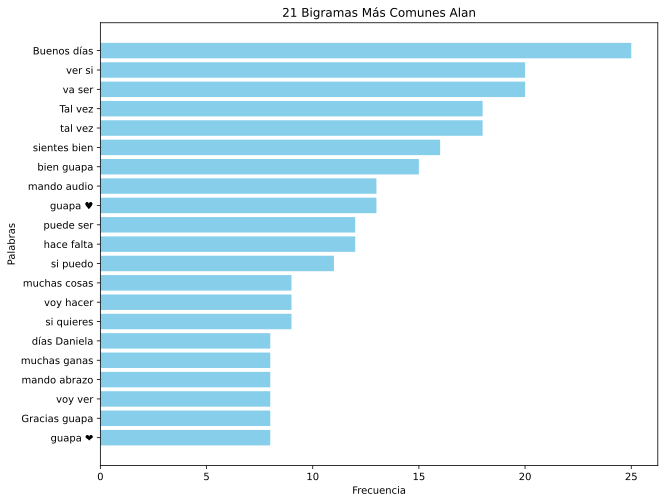

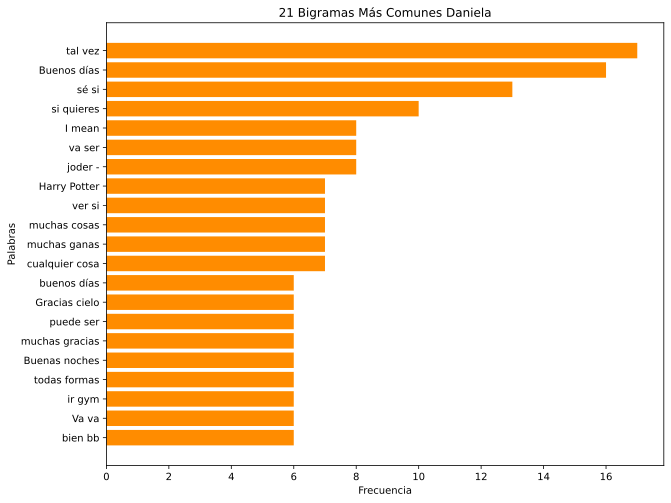

In [16]:
freqBi(frecuencia_bigramasA,21,'skyblue','Alan')
freqBi(frecuencia_bigramasD,21,'darkorange','Daniela')

In [17]:
mediaD = 60
mediaA = 100
desviacion_std = 30
tamaño_arregloD = sum(bool_audDani)
tamaño_arreglo = sum(bool_audAlan)
arreglo_normalD = np.random.normal(loc=mediaD, scale=desviacion_std, size=tamaño_arregloD)
arreglo_normalA = np.random.normal(loc=mediaA, scale=desviacion_std, size=tamaño_arreglo)

print(f"Audio Promedio Daniela: {np.mean(arreglo_normalD)}, Horas audio: {(np.sum(abs(arreglo_normalD))/60)/60} ")
print(f"Audio Promedio Alan: {np.mean(arreglo_normalA)}, Horas audio: {(np.sum(abs(arreglo_normalA))/60)/60} ")

Audio Promedio Daniela: 60.53677030404296, Horas audio: 7.47227095322393 
Audio Promedio Alan: 102.3200360401853, Horas audio: 8.242447347681594 
